In [1]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def read_files(file_list):
    dfs = []
    for file in file_list:
        with open(file) as f:
            data = json.load(f)
            
        print(type(data))
        dfs.extend(data)
        # break
    # df = pd.DataFrame(dfs)
    return dfs

TEMPLATE_PATTERNS = [
    ("Contact",         r"^Are there any moments in the video where two or more objects collide or make physical contact\?$"),
    ("Object Count",    r"^How many distinct physical objects appear during the video\?$"),
    ("Stop Count",      r"^How many objects come to a complete stop during the video that we can see\?$"),
    ("Rolling Count",   r"^How many objects display rolling motion at any point in the video\?$"),
    ("Collision Participants",  r"^How many unique objects were involved in collision throughout the video\?$"),
    # ("top_collider", r"^Which object(?:\(s\))? were involved in the most collisions with other objects\?$"),
    ("Top Collider", r"^Which object (?:was|were) involved in the most collisions with other objects\?$"),
  
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    ("Kinetic Energy Loss (System)", r"^What percentage of the system[’']s kinetic energy was lost when the .+ collided with the .+\?$"),
    # ("kinetic_loss_system",
    #                     r"^What percentage of the system(?:’|'s) kinetic energy was lost when the .+ collided with the .+\?$"),
    
    ("Kinetic Energy Loss (Object)",r"^How much kinetic energy did .+ lose during the collision\?$"),
    # ("collision_duration", r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\\?$"),
    ("Collision Duration", r"^How long did the collision between .+ and .+ last \(video fps is \d+\)\?$"),
# How long did the collision between darkcyan sphere and hotpink sphere last (video fps is 25)?
    # ("collision_duration",
    #                     r"^How long did the collision between the .+ and the .+ last(?: \(video fps is \d+\))?\?$"),
    ("Stationary Time", r"^How many seconds did the .+ spend stationary\?$"),
    ("Stationary Start", r"^At what time in the video does the .+ first become stationary\?$"),
    ("Max Friction",    r"^Which object had the highest friction coefficient\?$"),

]

def assign_template(q):
    for name, pat in TEMPLATE_PATTERNS:
        if re.match(pat, q):
            return name
    print('q', q)
    return "unknown"

def read_and_label(files, model_name):
    all_data = []
    for f in files:
        with open(f) as file:
            data = json.load(file)
            for entry in data:
                entry['model'] = model_name
                all_data.append(entry)
    df = pd.DataFrame(all_data)
    df['template'] = df['question'].apply(assign_template)
    df = df[df['template'] != 'unknown'].copy()
    df['model'] = df['model'].astype('category')
    df['option'] = df['option'].astype('category')
    df['correct'] = df['correct'].astype(int)
    return df

def get_info(df):
    df["template"] = df["question"].apply(assign_template)

    # 2) (Optionally) inspect how many fell into 'unknown'
    # n_unknown = (df["template"]=="unknown").sum()
    # if n_unknown>0:
    #     print(f"⚠️  {n_unknown} questions didn’t match any pattern and are labeled 'unknown'.")
    
    # #  Drop unknowns before plotting
    df = df[df["template"]!="unknown"]
    
    # Summarize and pivot
    summary = (
        df
        .groupby(["template","option"])
        .agg(n_total=("correct","count"), n_correct=("correct","sum"))
        .reset_index()
    )
    summary["success_pct"] = summary["n_correct"] / summary["n_total"] * 100
    pivot = summary.pivot(index="template", columns="option", values="success_pct").fillna(0)
    
    # If pivot is empty, bail out
    if pivot.empty:
        print("❗ No templates remained after filtering — check your patterns.")
    else:
        #  Plot
        labels = pivot.index.tolist()
        x = np.arange(len(labels))
        width = 0.2
    
        fig, ax = plt.subplots()
        for i, opt in enumerate(pivot.columns):
            ax.bar(x + i*width, pivot[opt], width, label=opt)
    
        ax.set_xticks(x + width*(len(pivot.columns)-1)/2)
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_xlabel("Question Template")
        ax.set_ylabel("Success Rate (%)")
        ax.set_title("Model Success Rate by Template and Condition")
        ax.legend()
    
        plt.tight_layout()
        plt.show()
        # fig.savefig('InternVL3_2B.png', dpi=fig.dpi)
    return pivot

def process_model(file_list, model_name):
    data = read_files(file_list)
    df = pd.DataFrame(data)
    df["template"] = df["question"].apply(assign_template)
    df = df[df["template"] != "unknown"]
    
    # Calculate success rate per template and option
    summary = (
        df.groupby(["template", "option"])
          .agg(n_total=("correct", "count"), n_correct=("correct", "sum"))
          .reset_index()
    )
    summary["success_rate"] = summary["n_correct"] / summary["n_total"] * 100
    summary["model"] = model_name
    return summary
    return summary[["model", "template", "option", "success_rate"]]


def bootstrap_accuracy(df, n_bootstrap=30):
    df['model'] = df['model'].astype('category')
    df['option'] = df['option'].astype('category')
    results = []
    for model in df['model'].cat.categories:
        for option in df['option'].cat.categories:
            for template in df['template'].unique():
                group = df[(df['model'] == model) & 
                           (df['option'] == option) & 
                           (df['template'] == template)]
                if len(group) == 0:
                    continue
                for _ in range(n_bootstrap):
                    sample = group.sample(frac=1, replace=True)
                    acc = sample['correct'].mean() * 100
                    results.append({
                        'model': model,
                        'option': option,
                        'template': template,
                        'accuracy': acc
                    })
    return pd.DataFrame(results)


In [2]:
model_files = {
    "InternVL3-2B": [
        "./experiments/results/3-intern_socres-1.json",
        "./experiments/results/3-intern_socres-2.json",
        "./experiments/results/3-intern_socres-3.json",
    ],
    "InternVideo2.5-Chat-8B": [
        "./experiments/results/intern_socres-1.json",
        "./experiments/results/intern_socres-2.json",
        "./experiments/results/intern_socres-3.json",
        "./experiments/results/intern_socres-4.json",
        "./experiments/results/intern_socres-5.json",
        "./experiments/results/intern_socres-5.json",

    ],
    "VideoLLaMA3-7B": [
        "./experiments/results/llama_socres-1.json",
        "./experiments/results/llama_socres-2.json",
        "./experiments/results/llama_socres-3.json",
        "./experiments/results/llama_socres-3.0.json",
        "./experiments/results/llama_socres-4.json",
        "./experiments/results/llama_socres-4.0.json",
        "./experiments/results/llama_socres-5.json",
        "./experiments/results/llama_socres-5.0.json",
        "./experiments/results/llama_socres-6.json",
        "./experiments/results/llama_socres-7.json",
        "./experiments/results/llama_socres-8.json",
    ]

}
dfs = []
for model_name, files in model_files.items():
    dfs.append(read_and_label(files, model_name))
df_raw = pd.concat(dfs, ignore_index=True)

# df['template'] = df['question'].apply(assign_template)

print(f"Loaded raw data shape: {df_raw.shape}")
print(f"Unique models: {df_raw['model'].unique()}")
print(f"Unique options: {df_raw['option'].unique()}")
print(f"Unique templates: {df_raw['template'].unique()}")


Loaded raw data shape: (642380, 12)
Unique models: ['InternVL3-2B' 'InternVideo2.5-Chat-8B' 'VideoLLaMA3-7B']
Unique options: ['no_additional_info', 'taxonomy_only', 'physics_only', 'taxonomy_and_physics']
Categories (4, object): ['no_additional_info', 'physics_only', 'taxonomy_and_physics', 'taxonomy_only']
Unique templates: ['Contact' 'Object Count' 'Stop Count' 'Rolling Count'
 'Collision Participants' 'Top Collider' 'Kinetic Energy Loss (System)'
 'Collision Duration' 'Stationary Time' 'Stationary Start' 'Max Friction']


In [12]:
df_raw

,scene_id,question,answer,answer_options,response,correct,error,option,prompt_length,model,template,options
0,0,Are there any moments in the video where two o...,Yes,None,no,0,value,no_additional_info,294.0,InternVL3-2B,Contact,NaN
1,0,How many distinct physical objects appear duri...,5,None,1,0,value,no_additional_info,286.0,InternVL3-2B,Object Count,NaN
2,0,How many objects come to a complete stop durin...,1,None,0,0,value,no_additional_info,292.0,InternVL3-2B,Stop Count,NaN
3,0,How many objects display rolling motion at any...,3,None,0,0,value,no_additional_info,289.0,InternVL3-2B,Rolling Count,NaN
4,0,How many unique objects were involved in colli...,2,None,1,0,value,no_additional_info,288.0,InternVL3-2B,Collision Participants,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
642375,3999,How many seconds did the hotpink sphere spend ...,0.00s,NaN,0.00s,1,None,taxonomy_and_physics,NaN,VideoLLaMA3-7B,Stationary Time,"[0.00s, 0.50s, 0.25s, 1.00s]"
642376,3999,How many seconds did the grey box spend statio...,13.56s,NaN,13.56s,1,None,taxonomy_and_physics,NaN,VideoLLaMA3-7B,Stationary Time,"[12.56s, 10.85s, 13.56s, 16.27s]"
642377,3999,At what time in the video does the grey box fi...,1.08s,NaN,0.08s,0,value,taxonomy_and_physics,NaN,VideoLLaMA3-7B,Stationary Start,"[0.68s, 1.48s, 1.08s, 0.08s]"
642378,3999,How many seconds did the mediumturquoise spher...,0.00s,NaN,0.00s,1,None,taxonomy_and_physics,NaN,VideoLLaMA3-7B,Stationary Time,"[0.25s, 0.50s, 1.00s, 0.00s]"


### Anova

In [14]:

accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].mean().reset_index()

# Convert accuracy to percentage
accuracy_summary['accuracy_pct'] = accuracy_summary['correct'] * 100

# Pivot to get each condition as a column for easier table generation
accuracy_table = accuracy_summary.pivot(index='model', columns='option', values='accuracy_pct')

# Rename columns for readability if needed
accuracy_table = accuracy_table.rename(columns={
    'no_additional_info': 'No Additional Info',
    'physics_only': 'Physics Only',
    'taxonomy_only': 'Taxonomy Only',
    'taxonomy_and_physics': 'Taxonomy + Physics'
})

# Optionally round to integer percentages
accuracy_table = accuracy_table.round(0).astype(int)

accuracy_table


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_71776/400673400.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].mean().reset_index()


option,No Additional Info,Physics Only,Taxonomy + Physics,Taxonomy Only
model,,,,
InternVL3-2B,25,24,28,30
InternVideo2.5-Chat-8B,41,43,44,38
VideoLLaMA3-7B,48,56,61,55


In [15]:
# print(df_raw.columns)
# df_raw[['model', 'option', 'template', 'correct']].head()
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_raw['option'] = df_raw['option'].astype('category')
df_raw['model'] = df_raw['model'].astype('category')
df_raw['template'] = df_raw['template'].astype('category')

# anova_model = ols('correct ~ C(model) + C(option) + C(template) + C(model):C(option):C(template)', data=df_raw).fit()
anova_model = ols('correct ~ C(model) + C(option) + C(model):C(option)', data=df_raw).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print(anova_table)


                           sum_sq        df             F         PR(>F)
C(model)              8004.220654       2.0  17600.907035   0.000000e+00
C(option)              323.245224       3.0    473.867424  1.325024e-307
C(model):C(option)     381.410681       6.0    279.568086   0.000000e+00
Residual            146062.222907  642368.0           NaN            NaN


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_raw['group'] = df_raw['model'].astype(str) + "_" + df_raw['option'].astype(str)
tukey = pairwise_tukeyhsd(endog=df_raw['correct'], groups=df_raw['group'], alpha=0.05)
tukey.summary()


group1,group2,meandiff,p-adj,lower,upper,reject
InternVL3-2B_no_additional_info,InternVL3-2B_physics_only,-0.0048,0.8844,-0.0143,0.0047,False
InternVL3-2B_no_additional_info,InternVL3-2B_taxonomy_and_physics,0.0275,0.0,0.018,0.037,True
InternVL3-2B_no_additional_info,InternVL3-2B_taxonomy_only,0.0528,0.0,0.0433,0.0622,True
InternVL3-2B_no_additional_info,InternVideo2.5-Chat-8B_no_additional_info,0.1571,0.0,0.1478,0.1663,True
InternVL3-2B_no_additional_info,InternVideo2.5-Chat-8B_physics_only,0.1858,0.0,0.1766,0.1951,True
InternVL3-2B_no_additional_info,InternVideo2.5-Chat-8B_taxonomy_and_physics,0.1941,0.0,0.1849,0.2034,True
InternVL3-2B_no_additional_info,InternVideo2.5-Chat-8B_taxonomy_only,0.1343,0.0,0.125,0.1435,True
InternVL3-2B_no_additional_info,VideoLLaMA3-7B_no_additional_info,0.2265,0.0,0.2167,0.2364,True
InternVL3-2B_no_additional_info,VideoLLaMA3-7B_physics_only,0.3076,0.0,0.2977,0.3174,True
InternVL3-2B_no_additional_info,VideoLLaMA3-7B_taxonomy_and_physics,0.3652,0.0,0.3553,0.375,True


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_71776/1080286188.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].mean().reset_index()


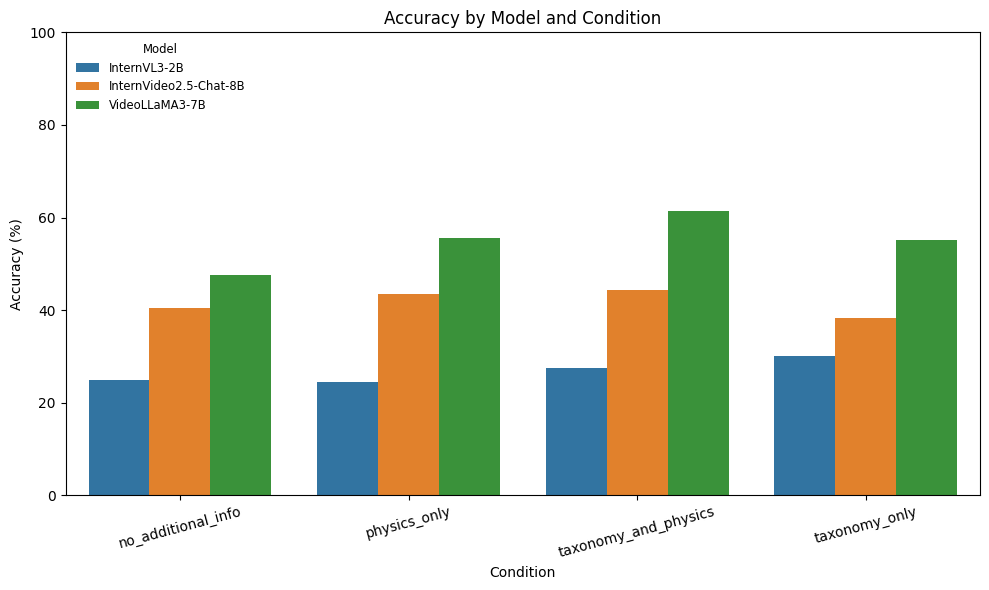

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].mean().reset_index()
accuracy_summary['accuracy_pct'] = accuracy_summary['correct'] * 100

plt.figure(figsize=(10,6))
sns.barplot(data=accuracy_summary, x='option', y='accuracy_pct', hue='model')

plt.title('Accuracy by Model and Condition')
plt.ylabel('Accuracy (%)')
plt.xlabel('Condition')

plt.ylim(0, 100)  # y-axis height 0 to 100%

plt.xticks(rotation=15)

# Legend smaller and placed top-left inside plot
plt.legend(title='Model', loc='upper left', fontsize='small', title_fontsize='small', frameon=False)

plt.tight_layout()
plt.show()


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_71776/2891284059.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].agg(['mean', 'std', 'count']).reset_index()


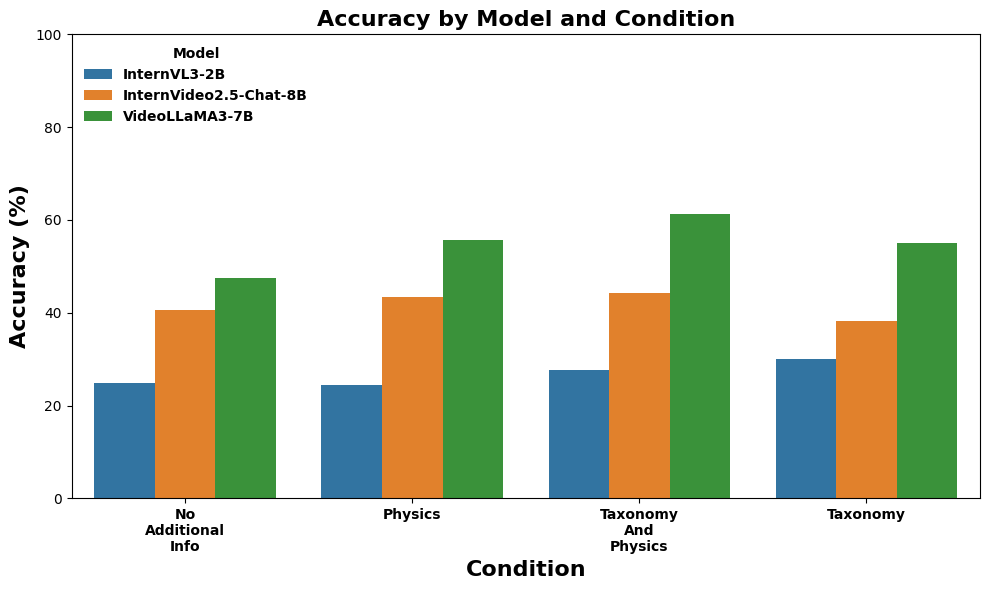

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_summary = df_raw.groupby(['model', 'option'])['correct'].agg(['mean', 'std', 'count']).reset_index()
accuracy_summary['accuracy_pct'] = accuracy_summary['mean'] * 100
accuracy_summary['se'] = accuracy_summary['std'] / np.sqrt(accuracy_summary['count'])

accuracy_summary['option_label'] = accuracy_summary['option'].str.replace('_', '\n').str.replace("only", "").str.title()

plt.figure(figsize=(10,6))

# custom_palette = {
#     'InternVL3-2B': '#FF69B4',   # Hot pink
#     'InternVideo2.5-Chat-8B': '#8A2BE2',  # Blue violet
#     'VideoLLaMA3-7B': '#00CED1',  # Dark turquoise
#     # 'InternVL3-2B': '#FFD700',  # Gold
#     # 'InternVideo2.5-Chat-8B': '#FFB6C1',  # Light pink
#     # 'VideoLLaMA3-7B': '#7FFFD4'  # Aquamarine
# }


# sns.color_palette("rocket", as_cmap=True)

# sns.barplot(data=accuracy_summary, x='option_label', y='accuracy_pct', hue='model')
sns.barplot(
    data=accuracy_summary,
    x='option_label',
    y='accuracy_pct',
    hue='model',
    # palette=custom_palette
)


plt.title('Accuracy by Model and Condition',  fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold', fontsize=16)
plt.xlabel('Condition', fontsize=16, fontweight='bold')
# plt.xticklabels( fontweight='bold')
plt.xticks(fontweight='bold')

plt.ylim(0, 100)

leg = plt.legend(title='Model', loc='upper left', fontsize='medium', title_fontsize='medium', frameon=False)
leg.get_title().set_fontweight('bold')
for text in leg.get_texts():
    text.set_fontweight('bold')
    

plt.tight_layout()
plt.savefig("accuracy_by_model.png", dpi=300, bbox_inches='tight')  # Save the figure
plt.show()


In [19]:
df_boot = bootstrap_accuracy(df_raw, n_bootstrap=30)
print(f"Bootstrapped data shape: {df_boot.shape}")

# === Run two-way ANOVA for each question template ===
for template in df_boot['template'].unique():
    df_sub = df_boot[df_boot['template'] == template].copy()
    df_sub['model'] = df_sub['model'].astype('category')
    df_sub['option'] = df_sub['option'].astype('category')
    
    model_formula = 'accuracy ~ C(model) + C(option) + C(model):C(option)'
    model = ols(model_formula, data=df_sub).fit()
    anova_res = sm.stats.anova_lm(model, typ=2)
    print(f"\nTwo-way ANOVA results for template '{template}':\n", anova_res)

Bootstrapped data shape: (3960, 4)

Two-way ANOVA results for template 'Contact':
                           sum_sq     df             F         PR(>F)
C(model)            46080.356809    2.0  37516.124283   0.000000e+00
C(option)            7542.224222    3.0   4093.646272  5.815490e-271
C(model):C(option)  10954.827534    6.0   2972.941905  1.632306e-295
Residual              213.720960  348.0           NaN            NaN

Two-way ANOVA results for template 'Object Count':
                            sum_sq     df              F  PR(>F)
C(model)            256224.744269    2.0  354544.391218     0.0
C(option)            77435.932071    3.0   71433.317842     0.0
C(model):C(option)   26303.656795    6.0   12132.335893     0.0
Residual               125.747598  348.0            NaN     NaN

Two-way ANOVA results for template 'Stop Count':
                           sum_sq     df            F         PR(>F)
C(model)             9842.470073    2.0  9341.106449  4.088781e-303
C(option)   

In [21]:
pivot.to_csv('pivot.csv')

In [22]:
pivot = df_raw.pivot_table(index=["template", "option"], columns="model", values="correct")
pivot

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_71776/3770024569.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_raw.pivot_table(index=["template", "option"], columns="model", values="correct")


model                                              InternVL3-2B  \
template                     option                               
Collision Duration           no_additional_info        0.519591   
                             physics_only              0.532368   
                             taxonomy_and_physics      0.545145   
                             taxonomy_only             0.553663   
Collision Participants       no_additional_info        0.006250   
                             physics_only              0.012750   
                             taxonomy_and_physics      0.064500   
                             taxonomy_only             0.010250   
Contact                      no_additional_info        0.501000   
                             physics_only              0.420750   
                             taxonomy_and_physics      0.459000   
                             taxonomy_only             0.616500   
Kinetic Energy Loss (System) no_additional_info        0.251278   
                             physics_only              0.247871   
                             taxonomy_and_physics      0.236797   
                             taxonomy_only             0.247871   
Max Friction                 no_additional_info        0.830093   
                             physics_only              0.742994   
                             taxonomy_and_physics      0.496087   
                             taxonomy_only             0.921484   
Object Count                 no_additional_info        0.075750   
                             physics_only              0.094000   
                             taxonomy_and_physics      0.233000   
                             taxonomy_only             0.102500   
Rolling Count                no_additional_info        0.371000   
                             physics_only              0.377750   
                             taxonomy_and_physics      0.735750   
                             taxonomy_only             0.663750   
Stationary Start             no_additional_info        0.283497   
                             physics_only              0.284809   
                             taxonomy_and_physics      0.326667   
                             taxonomy_only             0.306776   
Stationary Time              no_additional_info        0.082188   
                             physics_only              0.085265   
                             taxonomy_and_physics      0.059009   
                             taxonomy_only             0.076239   
Stop Count                   no_additional_info        0.100250   
                             physics_only              0.153250   
                             taxonomy_and_physics      0.247250   
                             taxonomy_only             0.245500   
Top Collider                 no_additional_info        0.308500   
                             physics_only              0.308250   
                             taxonomy_and_physics      0.308500   
                             taxonomy_only             0.306750   

model                                              InternVideo2.5-Chat-8B  \
template                     option                                         
Collision Duration           no_additional_info                  0.378378   
                             physics_only                        0.353604   
                             taxonomy_and_physics                0.301051   
                             taxonomy_only                       0.301802   
Collision Participants       no_additional_info                  0.196622   
                             physics_only                        0.127027   
                             taxonomy_and_physics                0.138739   
                             taxonomy_only                       0.191667   
Contact                      no_additional_info                  0.656982   
                             physics_only                        0.665

In [20]:
best_model_per_question = df_all.groupby(['template', 'model'])['success_rate'].mean().unstack()
print("Best model per question template:")
best_model_per_question.idxmax(axis=1)

Best model per question template:


template
collision_duration               InternVL3-2B
collision_objs         InternVideo2.5-Chat-8B
contact                InternVideo2.5-Chat-8B
kinetic_loss_system    InternVideo2.5-Chat-8B
max_friction           InternVideo2.5-Chat-8B
object_count           InternVideo2.5-Chat-8B
rolling_count                    InternVL3-2B
stationary_start                 InternVL3-2B
stationary_time        InternVideo2.5-Chat-8B
stop_count             InternVideo2.5-Chat-8B
top_collider           InternVideo2.5-Chat-8B
dtype: object

### Plots

In [23]:
# custom_palette = {
#     'no_additional_info': '#FF69B4',          # Hot pink
#     'physics_only': '#8A2BE2', # Blue violet
#     'taxonomy_and_physics': '#00CED1',        # Dark turquoise
#     "taxonomy_only": "#FFD700"

# }
# custom_palette = {
#     'no_additional_info': '#8A2BE2',   # Muted Blue
#     'physics_only': '#ff7f0e',   # Vibrant Orange
#     'taxonomy_and_physics': '#2ca02c',   # Rich Green
#     'taxonomy_only': '#d62728',   # Strong Red
# }
# # custom_palette = {

#     'no_additional_info': '#003f5c',  # Dark Navy
#     'physics_only': '#bc5090',  # Raspberry Pink
#     'taxonomy_and_physics': '#ffa600',  # Golden Yellow
#     'taxonomy_only': '#58508d',  # Deep Purple
# }

# custom_palette = {
#     'no_additional_info': '#4E79A7',      # Steel Blue
#     'physics_only': '#F28E2B',            # Amber Orange
#     'taxonomy_and_physics': '#E15759',    # Brick Red
#     'taxonomy_only': '#76B7B2',           # Sage Green
# }




def plot_accuracy(df, model_name):
    summary = (
        df.groupby(["template", "option"])
          .agg(n_total=("correct", "count"), n_correct=("correct", "sum"))
          .reset_index()
    )
    summary["success_pct"] = summary["n_correct"] / summary["n_total"] * 100
    pivot = summary.pivot(index="template", columns="option", values="success_pct").fillna(0)

    labels = pivot.index.tolist()
    x = np.arange(len(labels))
    width = 0.2

    fig, ax = plt.subplots()

    for i, opt in enumerate(pivot.columns):
        print(opt)
        # color = custom_palette.get(opt, "#333333")
        ax.bar(x + i*width, pivot[opt], width, label=opt, )
               # color=color)

    ax.set_xticks(x + width*(len(pivot.columns)-1)/2)
    ax.set_xticklabels(labels, rotation=45, ha="right",  fontweight='bold')

    plt.title(f'Accuracy by {model_name} and Condition', fontweight='bold')
    plt.ylabel('Accuracy (%)', fontweight='bold')
    plt.xlabel('Condition', fontsize=12, fontweight='bold')
    plt.ylim(0, 100)

    leg = plt.legend(title='Condition', loc='upper left', fontsize='medium', title_fontsize='medium', frameon=False)
    leg.get_title().set_fontweight('bold')
    for text in leg.get_texts():
        text.set_fontweight('bold')

    plt.tight_layout()

    save_name = f"{model_name.replace('-', '_').replace('.', '_')}.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_88556/271465122.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["template", "option"])


no_additional_info
physics_only
taxonomy_and_physics
taxonomy_only


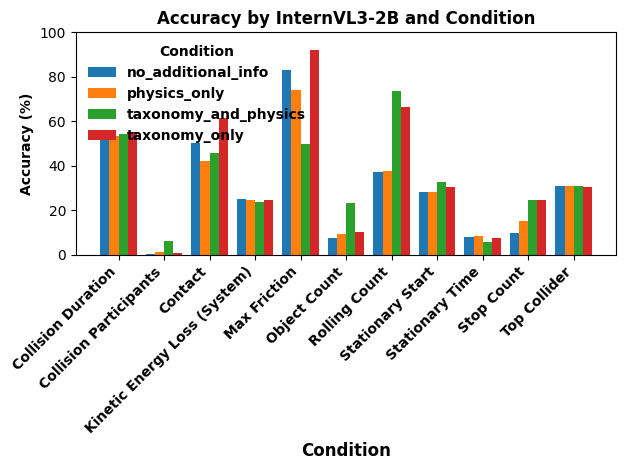

In [5]:
# InternVL3-2B
file_list = [
    "./experiments/results/3-intern_socres-1.json",
    "./experiments/results/3-intern_socres-2.json",
    "./experiments/results/3-intern_socres-3.json",
]

model_name = "InternVL3-2B"

df = read_and_label(file_list, model_name)
plot_accuracy(df, model_name)
# df = read_files(file_list)
# df = pd.DataFrame(df)
# pivot_interVl3 = get_info(df)

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_88556/271465122.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["template", "option"])


no_additional_info
physics_only
taxonomy_and_physics
taxonomy_only


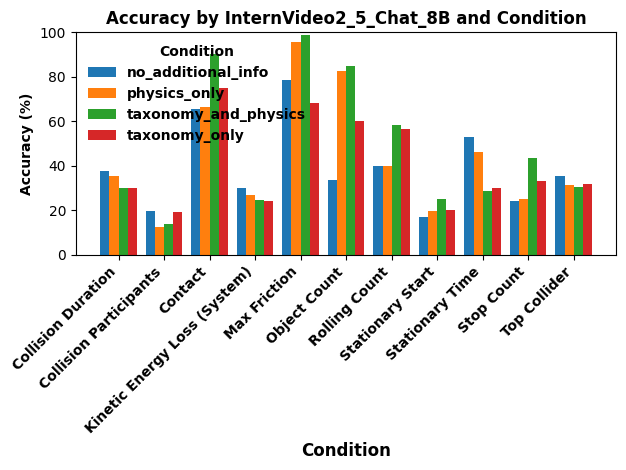

In [6]:
# InternVideo2_5_Chat_8B
file_list = [
    "./experiments/results/intern_socres-1.json",
    "./experiments/results/intern_socres-2.json",
    "./experiments/results/intern_socres-3.json",
    "./experiments/results/intern_socres-4.json",
    "./experiments/results/intern_socres-5.json",
    "./experiments/results/intern_socres-5.json",
]

model_name = "InternVideo2_5_Chat_8B"

df = read_and_label(file_list, model_name)
plot_accuracy(df, model_name)
# df = read_files(file_list)
# df = pd.DataFrame(df)
# pivot_internVid2_5 = get_info(df)

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_88556/271465122.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["template", "option"])


no_additional_info
physics_only
taxonomy_and_physics
taxonomy_only


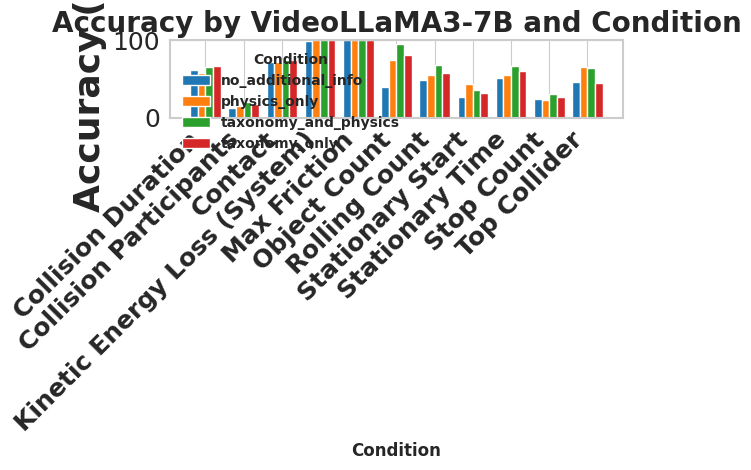

In [10]:
# VideoLLaMA3-7B
file_list = [
        "./experiments/results/llama_socres-1.json",
        "./experiments/results/llama_socres-2.json",
        "./experiments/results/llama_socres-3.json",
        "./experiments/results/llama_socres-3.0.json",
        "./experiments/results/llama_socres-4.json",
        "./experiments/results/llama_socres-4.0.json",
        "./experiments/results/llama_socres-5.json",
        "./experiments/results/llama_socres-5.0.json",
        "./experiments/results/llama_socres-6.json",
        "./experiments/results/llama_socres-7.json",
        "./experiments/results/llama_socres-8.json",
    ]

model_name = "VideoLLaMA3-7B"

df = read_and_label(file_list, model_name)
plot_accuracy(df, model_name)
# df = read_files(file_list)
# df = pd.DataFrame(df)
# pivot_video_llama3 = get_info(df)


In [11]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import matplotlib.pyplot as plt
import matplotlib

# Use seaborn whitegrid style (adjust if needed)
# plt.style.use('seaborn-whitegrid')
import seaborn as sns

sns.set_style('whitegrid')  # this sets the style globally

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Use seaborn style through seaborn package (recommended)
sns.set_style('whitegrid')

# Font and rcParams customizations
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.labelsize'] = 26
matplotlib.rcParams['axes.titlesize'] = 20
matplotlib.rcParams['axes.titleweight'] = 'bold'
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['legend.fontsize'] = 38
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['lines.linewidth'] = 3
matplotlib.rcParams['lines.markersize'] = 6
matplotlib.rcParams['lines.marker'] = 'o'
matplotlib.rcParams['axes.linewidth'] = 1.5


## Read

/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_71776/3936942294.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 0.95])


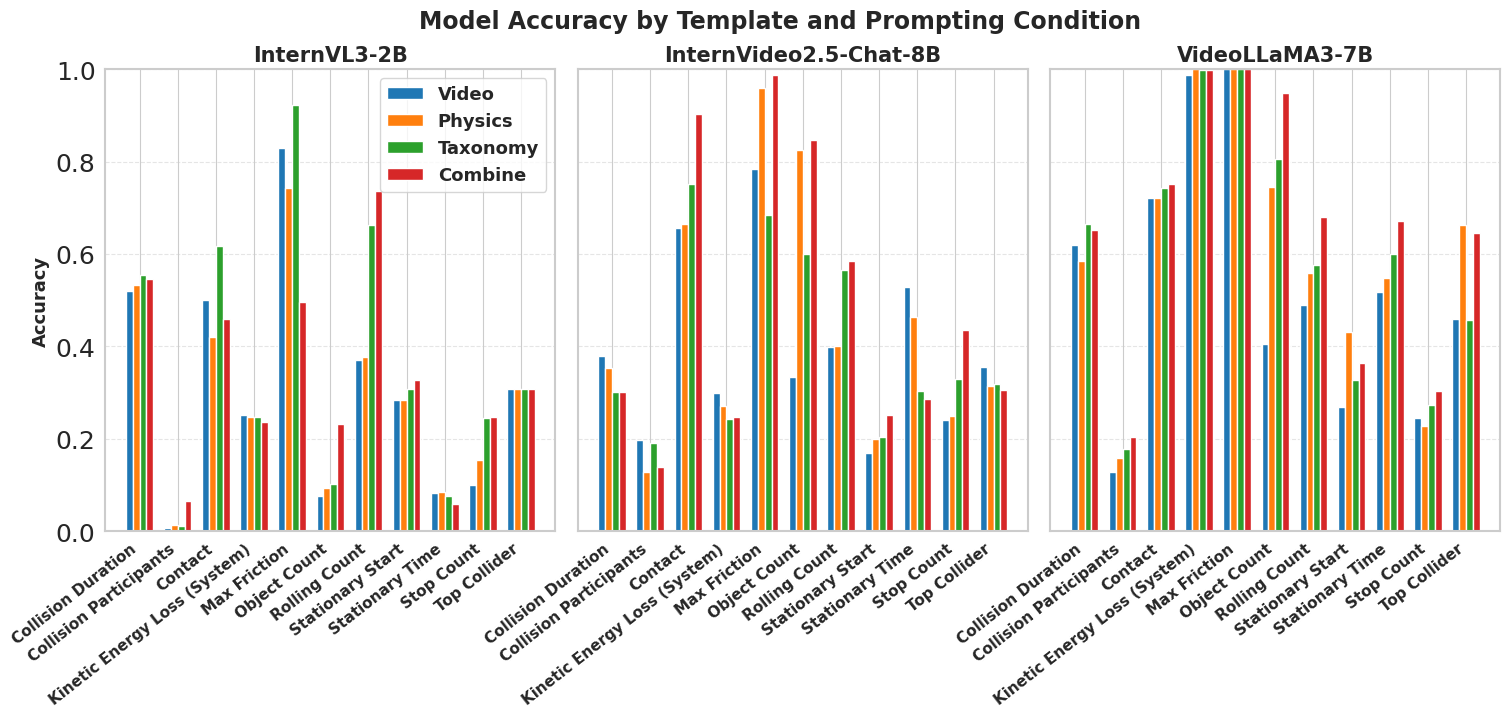

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.font_manager import FontProperties
bold_font = FontProperties(weight='bold',  size=13)  

# Read data
df = pd.read_csv('pivot.csv')

models = ['InternVL3-2B', 'InternVideo2.5-Chat-8B', 'VideoLLaMA3-7B']
conditions = ['no_additional_info', 'physics_only', 'taxonomy_only', 'taxonomy_and_physics']
condition_labels = ['Video', 'Physics', 'Taxonomy', 'Combine']
template_names = df['template'].unique()
subplot_labels = ['A', 'B', 'C']

# Font configs
title_font = {'fontsize': 15, 'fontweight': 'bold'}
label_font = {'fontsize': 13, 'fontweight': 'bold'}
tick_font = {'fontsize': 11, 'fontweight': 'bold'}

colors = plt.get_cmap('tab10').colors
width = 0.18

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, gridspec_kw={'wspace': 0.05})

for idx, (ax, model) in enumerate(zip(axes, models)):
    for i, (cond, label) in enumerate(zip(conditions, condition_labels)):
        acc = df[df['option'] == cond][[model, 'template']]
        acc = acc.set_index('template').reindex(template_names).reset_index()
        bars = ax.bar(
            np.arange(len(template_names)) + i*width - 1.5*width,
            acc[model].values,
            width=width,
            label=label,
            color=colors[i]
        )
    # Subplot label (A, B, C)
    # ax.text(-0.13, 1.05, subplot_labels[idx], transform=ax.transAxes,
            # fontsize=20, fontweight='bold', va='top', ha='center')
    ax.set_title(model, **title_font)
    ax.set_xticks(np.arange(len(template_names)))
    ax.set_xticklabels(template_names, rotation=38, ha='right', **tick_font)
    if idx == 0:
        ax.set_ylabel('Accuracy', **label_font)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    # ax.tick_params(axis='y', **tick_font)
    # ax.tick_params(axis='x', **tick_font)
    if idx == 0:
        ax.set_ylabel('Accuracy', **label_font)
        ax.legend(loc='upper right', frameon=True,prop=bold_font 
                 # prop={'weight': 'medium'}
                 ) 

    # if idx == 2:
    #     ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=11, frameon=True)

fig.suptitle('Model Accuracy by Template and Prompting Condition', fontsize=17, fontweight='bold')
fig.tight_layout(rect=[0, 0, 0.96, 0.95])

# Save figures
output_dir = "figures"
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, "model_accuracy_by_template_ABC.png"), dpi=300, bbox_inches='tight')
# fig.savefig(os.path.join(output_dir, "model_accuracy_by_template_ABC.pdf"), bbox_inches='tight')

plt.show()


In [3]:
count_df = (
    df_raw
    .groupby(['template', 'option'])
    .size()
    .reset_index(name='count')
)

# Pivot the counts to make each prompt condition a column
template_counts = count_df.pivot(
    index='template',
    columns='option',
    values='count'
).fillna(0).astype(int)


/var/folders/bf/x4w27yrx4md7qs_x4kjctl6r0000gn/T/ipykernel_46911/1380390648.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['template', 'option'])


In [4]:
display(template_counts)


option,no_additional_info,physics_only,taxonomy_and_physics,taxonomy_only
template,,,,
Collision Duration,3535,3535,3535,3535
Collision Participants,11895,11895,11895,11895
Contact,11895,11895,11895,11895
Kinetic Energy Loss (System),3535,3535,3535,3535
Max Friction,11782,11782,11782,11782
Object Count,11895,11895,11895,11895
Rolling Count,11895,11895,11895,11895
Stationary Start,27066,27066,27066,27066
Stationary Time,43307,43307,43307,43307


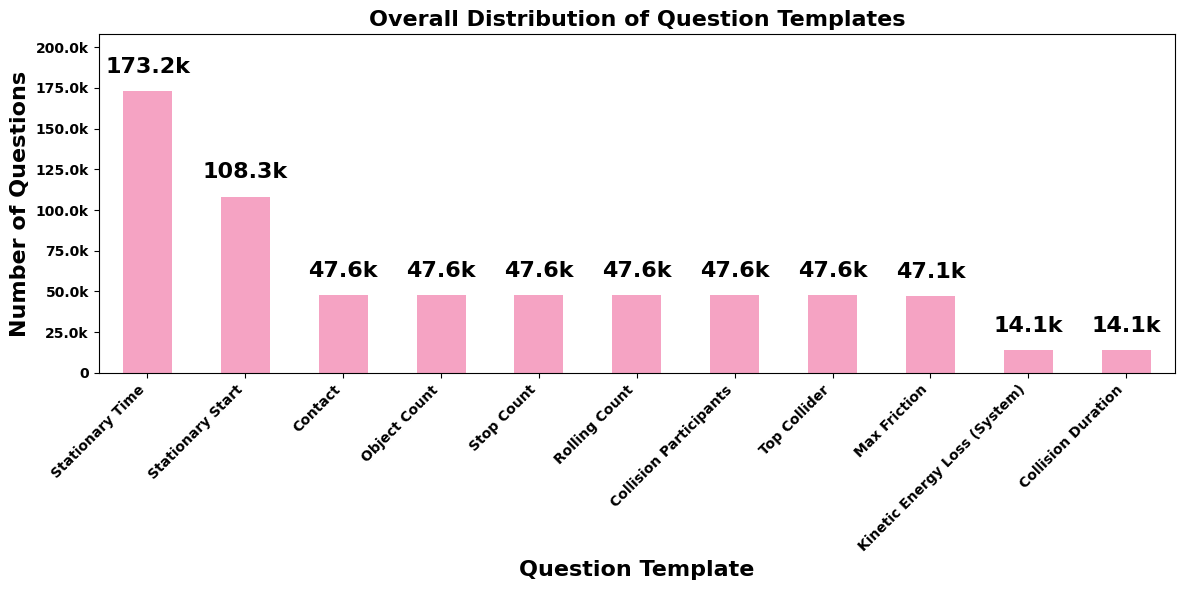

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def human_format(num):
    if num >= 1_000_000:
        return f"{num / 1_000_000:.1f}M"
    elif num >= 1_000:
        return f"{num / 1_000:.1f}k"
    else:
        return str(num)

# Compute max value for margin
value_counts = df_raw['template'].value_counts()
max_count = value_counts.max()

# 💜 Lavender – #D8B4E2
# 🌸 Blush Pink – #F5A3C3
# 🌿 Mint Green – #B2E6D4
# 💙 Baby Blue – #A3C7F3
# 🌈 Pale Lilac – #CFC8E7

plt.figure(figsize=(12, 6)) 
ax = value_counts.plot(kind='bar', color='#F5A3C3')

plt.title('Overall Distribution of Question Templates', fontsize=16, fontweight='bold')
plt.ylabel('Number of Questions',  fontsize=16, fontweight='bold')
plt.xlabel('Question Template',  fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()

# Add a 20% headroom so labels have room above the tallest bar
ax.set_ylim(0, max_count * 1.2)

# Format y-axis tick labels using the human_format function
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: human_format(int(y))))

# Annotate each bar with its height; offset relative to the max count
for p in ax.patches:
    value = p.get_height()
    # place label at 5% of max_count above the bar height
    y_position = value + max_count * 0.05
    ax.text(
        x=p.get_x() + p.get_width() / 2,
        y=y_position,
        s=human_format(int(value)),
        ha='center',
        va='bottom',
        fontsize=16,
        fontweight='bold'
    )

plt.savefig('overall_distribution_templates.png', dpi=300, bbox_inches='tight')
plt.show()
